# TOI Comparison

The purpose of this notebook is to compare the results of `astronet-vetting` with the sector 86 TOI list.

In [1]:
from astropy.table import join, Table, vstack
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.special
from tqdm.notebook import tqdm

## Data collection and cleanup

In [2]:
astronet_results = pd.read_csv(
    "data/20250429_181612_predictions_sector86.csv",
    names=["astro_id", "tic_id", "planetno", "model_no", "disp_p", "disp_e", "disp_n", "disp_j"],
    header=1
).drop(columns="model_no")
astronet_data = pd.read_csv(
    "data/astronet-vetting-tce-catalog-with-offsets-CORRECTED.csv",
    names=["tic_id", "smass", "srad", "tmag", "planetno", "epoch", "period", "depth", "duration", "sradest", "astro_id", "centroid_distance_arcsec"],
    index_col=0,
    header=1,
)[["astro_id", "tic_id", "planetno", "tmag", "period", "epoch", "depth", "duration", "centroid_distance_arcsec"]]
astronet_data["astro_id"] = astronet_data["astro_id"].astype(int)
astronet_data = astronet_data.merge(astronet_results, on=["astro_id", "tic_id", "planetno"])
astronet_data = Table.from_pandas(astronet_data)
astronet_data[:5]

astro_id,tic_id,planetno,tmag,period,epoch,depth,duration,centroid_distance_arcsec,disp_p,disp_e,disp_n,disp_j
int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
210086502,2100865,2,9.77854,1.1323019424448142,1817.5636363191736,137.60812968001446,0.2933866561900627,22.011604509306046,0.440983,0.050800033,0.053944737,0.45427227
210469602,2104696,2,8.6729,3.306940351232236,1819.98247872906,245.1538329026045,0.3267968206440816,9.107257537221027,0.24442814,0.21518059,0.045701984,0.49468914
210506702,2105067,2,9.8256,2.261021262129966,1817.9206107665664,6468.897950308928,0.1124190748377369,3.970616478124537,0.011324852,0.40260875,0.029062444,0.5570039
210511901,2105119,1,10.2692,2.261074437658549,1819.0303251472883,1102.064407311339,0.1106598251866275,98.77839275757252,0.508021,0.3545347,0.04177216,0.095672235
210631301,2106313,1,10.404,8.352945232467482,1824.4433038565408,2785.7427044222586,0.184422498158594,27.51781874375227,0.2440187,0.59438145,0.047025878,0.114573985


In [3]:
toi_data = (
    pd.read_csv("data/toi-plus-2025-07-16.csv", comment="#")[[
        "TIC", "Full TOI ID", "TOI Disposition", "TMag Value", "Orbital Epoch Value", "Orbital Period (days) Value",
        "Transit Duration (hours) Value", "Transit Depth Value", "Planet Number", "Detection Pipeline(s)"
    ]].rename(columns={
            "TIC": "tic_id",
            "Full TOI ID": "toi_id",
            "TOI Disposition": "toi_disposition",
            "TMag Value": "tmag",
            "Orbital Epoch Value": "epoch",
            "Orbital Period (days) Value": "period",
            "Transit Duration (hours) Value": "duration",
            "Transit Depth Value": "depth",
            "Planet Number": "planetno",
            "Detection Pipeline(s)": "detection_pipeline",
        }
    )
)
toi_data = Table.from_pandas(toi_data)
toi_data[:5]

tic_id,toi_id,toi_disposition,tmag,epoch,period,duration,depth,planetno,detection_pipeline
int64,float64,str2,float64,float64,float64,float64,float64,int64,str10
231663901,101.01,KP,12.352,1326.0091165519705,1.4303699496507394,1.6165994039943885,18960.712294362853,1,SPOC/QLP
149603524,102.01,KP,9.716,3187.9165707,4.4119378,3.65,15062.0,1,SPOC/QLP
336732616,103.01,KP,11.464,1327.25256,3.547854,3.494333,10424.3718,1,SPOC/QLP
231670397,104.01,KP,9.848,3150.6086768,4.0872956,5.586113047476104,3572.1712498597267,1,SPOC/QLP
144065872,105.01,KP,9.48,2084.58501,2.184666948720648,2.8652800157435805,11708.02285488866,1,SPOC/QLP


## Matching TOIs with astronet signals

We want to know which signals given to astronet are in the TOI list. However, we can't assume that the planet numbers within each TIC ID are consistent - for example, TOI `123.03` (the .03 indicating the planet number) could have been found as the _second_ planet during QLP's processing. So, we need to do some fancier matching that takes into account period and transit timing. We employ the method outlined in section 3.2 of [Coughlin, J. L., Thompson, S. E., Bryson, S. T., et al. 2014, AJ, 147, 119](https://doi.org/10.1088/0004-6256/147/5/119), calculating significances of the period and transit center matches. Following the paper, we consider a signal to be matched if $\sigma_P, \sigma_T > 3$ (if there are multiple matches, we take the strongest match).

We reject signals that have centroid distance greater than 21 arcsec as being off-target, as is planned for production processing.

This gives us a table of signals that appear in both the astronet signal list and the TOI list, which we use to calculate a recall vs. threshold curve.

In [4]:
def get_ephemeris_matches(astronet_rows, toi_rows):
    cartesian_table = join(
        astronet_rows, toi_rows, join_type="cartesian", table_names=["astronet", "toi"]
    )
    p_astronet = cartesian_table["period_astronet"]
    t_astronet = cartesian_table["epoch_astronet"]
    p_toi = cartesian_table["period_toi"]
    t_toi = cartesian_table["epoch_toi"]

    p_min = np.minimum(p_astronet, p_toi)
    delta_p = (p_astronet - p_toi) / p_min
    delta_p_prime = np.abs(delta_p - np.round(delta_p))
    sigma_p = np.sqrt(2) * scipy.special.erfcinv(delta_p_prime)
    cartesian_table["sigma_p"] = sigma_p

    delta_t = (t_astronet - t_toi) / p_min
    delta_t_prime = np.abs(delta_t - np.round(delta_t))
    sigma_t = np.sqrt(2) * scipy.special.erfcinv(delta_t_prime)
    cartesian_table["sigma_t"] = sigma_t

    cartesian_table["match_strength"] = sigma_p ** 2 + sigma_t ** 2
    best_match = cartesian_table[np.argmax(cartesian_table["match_strength"])]
    return best_match

matched_astronet_data = vstack(
    [
        get_ephemeris_matches(row, toi_data[toi_data["tic_id"] == row["tic_id"]])
        for row in astronet_data
        if row["tic_id"] in toi_data["tic_id"] and row["centroid_distance_arcsec"] < 21
    ]
)
# Here, `matched_astronet_data` contains the best match for each signal, but we want to throw out
# matches that don't meet the criterion \sigma_P, \sigma_T > 3.
matched_astronet_data = matched_astronet_data[
    (matched_astronet_data["sigma_p"] > 3) & (matched_astronet_data["sigma_t"] > 3)
]
matched_astronet_data

astro_id,tic_id_astronet,planetno_astronet,tmag_astronet,period_astronet,epoch_astronet,depth_astronet,duration_astronet,centroid_distance_arcsec,disp_p,disp_e,disp_n,disp_j,tic_id_toi,toi_id,toi_disposition,tmag_toi,epoch_toi,period_toi,duration_toi,depth_toi,planetno_toi,detection_pipeline,sigma_p,sigma_t,match_strength
int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,str2,float64,float64,float64,float64,float64,int64,str10,float64,float64,float64
1079208101,10792081,1,10.0223,10.169223927475723,1799.7990558583997,852.4763000877164,0.3059779783838527,15.59162078359481,0.86389405,0.053176608,0.027151348,0.055777855,10792081,5703.01,PC,10.022,3630.2822769,10.1695422,5.537,888.0,1,QLP,4.163813189137242,3.054643921428973,26.66818976075622
9629121801,96291218,1,10.3614,6.852782238715854,1820.6423506378444,5651.792021205773,0.1179439284743073,17.498706190464773,0.804379,0.100210026,0.034523483,0.060887408,96291218,1678.01,EB,10.361,2917.0908213,13.7058173,2.597,5788.0,1,QLP,4.1261203864565035,3.489803636819646,29.203598867091593
10267270901,102672709,1,9.86671,6.705397948163395,1818.592273922301,646.9056619951502,0.1845029737483702,8.04061746526377,0.835709,0.05507411,0.03224407,0.07697284,102672709,1686.01,PC,9.86671,1818.5978258650675,6.705325984067135,3.730293669358069,623.6644761909791,1,SPOC,4.40186610471792,3.3432643000209077,30.5538413836588
12262976101,122629761,1,9.47632,8.212323026438543,1824.784529780065,898.2532795020887,0.1725843037712241,14.649075863092666,0.85712016,0.03578176,0.03166587,0.07543211,122629761,6062.01,PC,9.476,2925.2343578,8.2125432,3.166,986.0,1,QLP,4.198995677032203,3.7490863573366813,31.687213210503153
14400687401,144006874,1,9.5951,2.367334830693894,1818.588226591344,592.4769042619762,0.0723693063297943,12.179007862032616,0.90116495,0.021811312,0.028431838,0.048591897,144006874,6058.01,PC,9.595,2935.9681891,2.3673676,1.045,550.0,1,QLP,4.346348189032544,3.3270829490186604,29.960223529957183
15487237501,154872375,1,9.02855,8.027704390519382,1684.155788757004,5705.497420703191,0.1887112916035109,2.5590570022382124,0.9549029,0.01601453,0.017212324,0.011870252,154872375,1135.01,CP,9.029,3466.3087098,8.0277331,4.292,5704.0,1,SPOC/QLP,4.634599019997049,3.600836506963335,34.44553162603752
15672471901,156724719,1,9.353,10.95685113126075,1818.1287533356551,4642.8877479362,0.1578058754106479,4.306639849802356,0.8390366,0.08895846,0.02920718,0.042797737,156724719,1653.01,PC,9.353,2935.725734,10.9568574,3.574,4327.0,1,QLP,5.0003950533607116,3.763651866545681,39.16902606222706
15941835302,159418353,2,9.812,8.30343628333698,1685.2269271091957,570.661925205283,0.089828093071782,13.414939897511523,0.8454507,0.041509356,0.03521251,0.07782744,159418353,1739.01,PC,9.812,2631.8205231,8.30329783725283,1.8911727042745496,560.3698799160642,1,SPOC,4.305330970722675,3.0722153890994828,27.974382164483536
19839024701,198390247,1,10.1426,6.58858873435318,1683.821290223064,852.3408489512707,0.0981224156335705,17.41411987844028,0.90110016,0.03177325,0.027408903,0.039717548,198390247,1453.01,PC,10.143,3660.4093704,6.5886877,1.678,852.0,1,SPOC/QLP,4.328383640939823,3.1314673263959962,28.540992559441165


Text(0.5, 1.0, 'Recall vs. disp_p Threshold on Sector 86 TOIs\nastronet-vetting_20250429_181612')

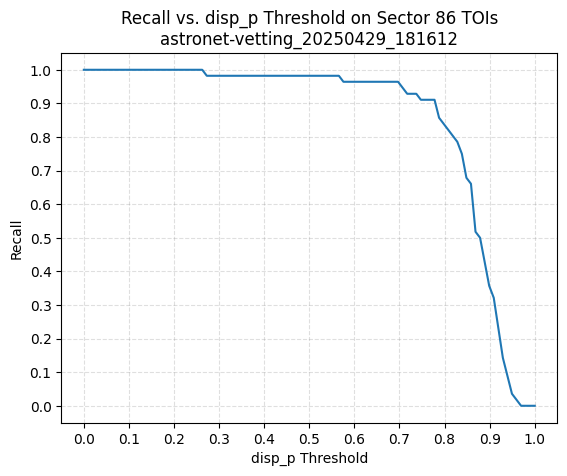

In [5]:
disp_p_thresholds = np.linspace(0, 1, 100)
disp_p_recall = np.sum(
    matched_astronet_data["disp_p"].data[np.newaxis, :] > disp_p_thresholds[:, np.newaxis], axis=1
) / len(matched_astronet_data)
plt.plot(disp_p_thresholds, disp_p_recall)
plt.xlabel("disp_p Threshold")
plt.ylabel("Recall")
plt.xticks(np.linspace(0, 1, 11))
plt.yticks(np.linspace(0, 1, 11))
plt.grid(c="gray", ls="--", alpha=0.25)
plt.title("Recall vs. disp_p Threshold on Sector 86 TOIs\nastronet-vetting_20250429_181612")
# plt.savefig("plots/recall_vs_disp_p_threshold_20250429_181612.pdf")

## Ranking by disp_p

Another idea we had for deciding which targets to "pass" from astronet-vetting's results was to take the top X signals by `disp_p` score, with X in the range of 200-300. We can create a similar recall vs. threshold plot, where now the threshold is the number of targets considered, by finding the "rank" of each TOI signal among all the astronet signals and checking whether it would have been part of the top X signals.

In [6]:
sorted_disp_p_scores = np.sort(astronet_data["disp_p"])
matched_astronet_data["disp_p_rank"] = len(sorted_disp_p_scores) - np.searchsorted(
    sorted_disp_p_scores, matched_astronet_data["disp_p"], side="left"
)

Text(0.5, 1.0, 'Recall vs. disp_p Rank Threshold on Sector 86 TOIs\nastronet-vetting_20250429_181612')

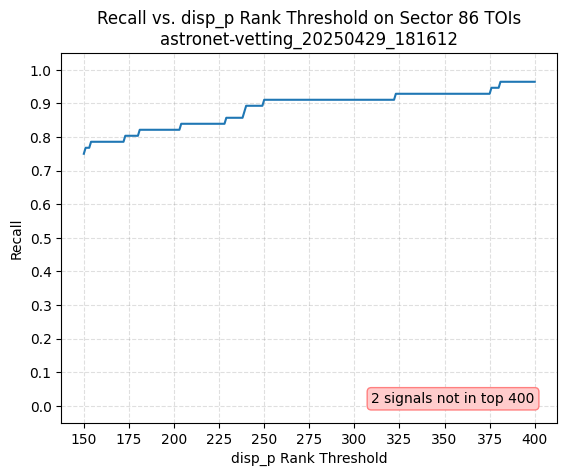

In [7]:
n_signals_thresholds = np.arange(150, 401)
n_signals_recall = np.sum(
    matched_astronet_data["disp_p_rank"].data[np.newaxis, :] < n_signals_thresholds[:, np.newaxis], axis=1
) / len(matched_astronet_data)
plt.plot(n_signals_thresholds, n_signals_recall)
plt.text(
    400, 0,
    f"{np.sum(matched_astronet_data["disp_p_rank"] > np.max(n_signals_thresholds))} signals not in top {n_signals_thresholds.max()}",
    ha="right", va="bottom",
    bbox=dict(boxstyle="round",
               ec=(1., 0.5, 0.5),
               fc=(1., 0.8, 0.8),
               )
)
plt.xlabel("disp_p Rank Threshold")
plt.ylabel("Recall")
plt.ylim(-0.05, 1.05)
plt.xticks(np.arange(150, 401, 25))
plt.yticks(np.linspace(0, 1, 11))
plt.grid(c="gray", ls="--", alpha=0.25)
plt.title("Recall vs. disp_p Rank Threshold on Sector 86 TOIs\nastronet-vetting_20250429_181612")
# plt.savefig("plots/recall_vs_rank_threshold_20250429_181612.pdf")

## Complete Report

This section simply combines the two plots we've already produced into a single, unified report.

Text(0.5, 0.98, 'Recall of astronet-vetting_20250429_181612 on sector 86 TOIs\nUsing 56 TOI signals (from 3332 astronet signals run)')

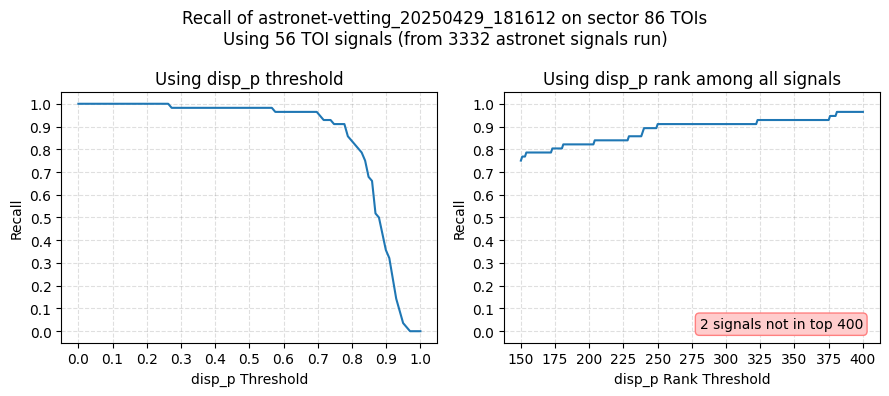

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4), layout="tight")

ax1.plot(disp_p_thresholds, disp_p_recall)
ax1.set(
    title="Using disp_p threshold",
    xlabel="disp_p Threshold",
    ylabel="Recall",
    xticks=np.linspace(0, 1, 11),
    yticks=np.linspace(0, 1, 11),
)
ax1.grid(c="gray", ls="--", alpha=0.25)

ax2.plot(n_signals_thresholds, n_signals_recall)
ax2.text(
    400, 0,
    f"{np.sum(matched_astronet_data["disp_p_rank"] > np.max(n_signals_thresholds))} signals not in top {n_signals_thresholds.max()}",
    ha="right", va="bottom",
    bbox=dict(boxstyle="round",
               ec=(1., 0.5, 0.5),
               fc=(1., 0.8, 0.8),
               )
)
ax2.set(
    title="Using disp_p rank among all signals",
    xlabel="disp_p Rank Threshold",
    ylabel="Recall",
    xticks=np.arange(150, 401, 25),
    yticks=np.linspace(0, 1, 11),
    ylim=(-0.05, 1.05),
)
ax2.grid(c="gray", ls="--", alpha=0.25)

fig.suptitle(
    "Recall of astronet-vetting_20250429_181612 on sector 86 TOIs\n"
    f"Using {len(matched_astronet_data)} TOI signals (from {len(astronet_data)} astronet signals run)"
)
# fig.savefig("plots/sector86-tois-recall-astronet-vetting_20250429_181612.pdf")

## QLP Operator Recall

In this section, we calculate the recall of the QLP operator from sector 86 - that is, how many of the TOIs in the sector did the operator send in for vetting?

In [16]:
operator_signals = Table.read("data/pcs.ls", names=["tic_id", "planetno"], format="ascii")
operator_signals[:5]

tic_id,planetno
int64,int64
104734832,1
117322779,1
121070864,1
121526198,1
122035569,2


In [ ]:
join(matched_astronet_data["tic_id_astronet", "planetno_astronet"], operator_signals,
     keys_left=["tic_id_astronet", "planetno_astronet"], keys_right=["tic_id", "planetno"])[
    "tic_id", "planetno"
    ].write("s86_operator_passed_tois.ls", format="ascii.no_header", overwrite=True)

## Writing useful lists

Here we record the list of the top 250 signals, and a CSV file with useful information about the matched TOIs (including the model predictions, ranks, and whether the signal was passed by the QLP operator) so that others can investigate them further.

In [12]:
astronet_data.sort("disp_p", reverse=True)
astronet_data["tic_id", "planetno"][:250].write("s86_astronet_vetting_pcs.ls", format="ascii.no_header")

In [58]:
csv_data = matched_astronet_data["toi_id", "tic_id_astronet", "planetno_astronet", "tmag_astronet", "period_toi", "epoch_toi",
    "duration_toi", "depth_toi", "centroid_distance_arcsec", "disp_p", "disp_e", "disp_n", "disp_j", "disp_p_rank"]
csv_data.sort("disp_p")
csv_data["operator_passed"] = np.isin(
    np.array(csv_data["tic_id_astronet", "planetno_astronet"])
        .astype([("tic_id", np.int64), ("planetno", np.int64)]),
    operator_signals,
)
csv_data.write("s86_astronet_vetting_tois.csv", overwrite=True)

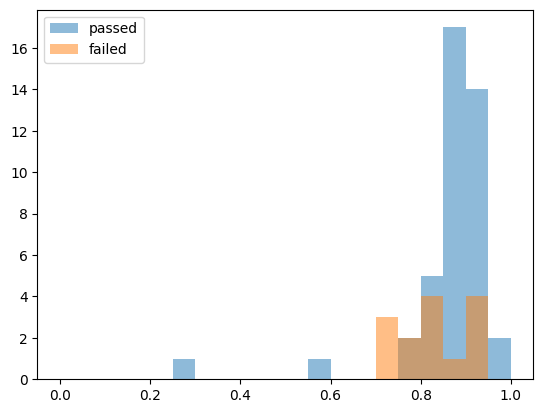

In [70]:
plt.hist(csv_data[csv_data["operator_passed"]]["disp_p"], label="passed", bins=np.linspace(0, 1, 21), alpha=0.5)
plt.hist(csv_data[~csv_data["operator_passed"]]["disp_p"], label="failed", bins=np.linspace(0, 1, 21), alpha=0.5)
plt.legend()